<a href="https://colab.research.google.com/github/isaiahk6/Retinal-oct-classification/blob/main/RetinalClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Colab setup — upload your kaggle.json (from kaggle.com/settings) first
!pip install -q kaggle
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d paultimothymooney/kermany2018
!unzip -q kermany2018.zip -d oct_data

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [7]:
# The dataset ships with an inconsistent folder name ("OCT2017 " with a trailing space
# on some mirrors). Detect the actual paths instead of hardcoding them.
import os

def find_dir(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    raise FileNotFoundError(f"Could not find a '{target}' folder under {root}")

TRAIN_DIR = find_dir("oct_data", "train")
TEST_DIR  = find_dir("oct_data", "test")
print("Train dir:", TRAIN_DIR)
print("Test dir: ", TEST_DIR)
print("Classes:", sorted(os.listdir(TRAIN_DIR)))

Train dir: oct_data/OCT2017 /train
Test dir:  oct_data/OCT2017 /test
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [8]:
import os

def find_dir(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if "__MACOSX" in dirpath:
            continue  # skip macOS zip artifacts
        if target in dirnames:
            return os.path.join(dirpath, target)
    raise FileNotFoundError(f"Could not find a '{target}' folder under {root}")

TRAIN_DIR = find_dir("oct_data", "train")
TEST_DIR  = find_dir("oct_data", "test")
print("Train dir:", TRAIN_DIR)
print("Test dir: ", TEST_DIR)

# filter to real class folders only (real dirs, not junk files like "._CNV")
classes = sorted(d for d in os.listdir(TRAIN_DIR)
                  if os.path.isdir(os.path.join(TRAIN_DIR, d)) and not d.startswith("."))
print("Classes:", classes)

Train dir: oct_data/OCT2017 /train
Test dir:  oct_data/OCT2017 /test
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [9]:
for cls in sorted(d for d in os.listdir(TRAIN_DIR)
                   if os.path.isdir(os.path.join(TRAIN_DIR, d)) and not d.startswith(".")):
    n = len([f for f in os.listdir(os.path.join(TRAIN_DIR, cls)) if not f.startswith(".")])
    print(f"{cls:10s}: {n:6d} images")

CNV       :  37205 images
DME       :  11348 images
DRUSEN    :   8616 images
NORMAL    :  26315 images


In [10]:
for cls in sorted(os.listdir(TRAIN_DIR)):
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"{cls:10s}: {n:6d} images")

CNV       :  37205 images
DME       :  11348 images
DRUSEN    :   8616 images
NORMAL    :  26315 images


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

IMG_SIZE = 128        # OCT scans are large greyscale images; 128x128 keeps training fast on a free GPU
BATCH_SIZE = 64
SEED = 42
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Modest augmentation: OCT scans are always upright and roughly centered, so we avoid aggressive
# rotation/flipping that would create anatomically implausible images. Small shifts and slight
# brightness/contrast jitter approximate scan-to-scan variation without distorting the anatomy.
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# The Kaggle test split is small (only ~32 images/class) since it was designed for spot-checking,
# not full evaluation. We instead carve our own validation + test sets out of the larger train split.
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
class_names = full_train.classes
print("Class -> index mapping:", full_train.class_to_idx)

n_total = len(full_train)
n_val   = int(0.10 * n_total)
n_test  = int(0.10 * n_total)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_train, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

Using device: cuda
Class -> index mapping: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}


In [12]:
# random_split shares one underlying dataset across all three splits, so changing .transform on
# one subset silently changes it for all of them. Use a thin wrapper instead so train keeps
# augmentation while val/test stay clean.
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset.dataset.samples[self.subset.indices[idx]]
        from PIL import Image
        img = Image.open(img).convert("L")
        img = self.transform(img)
        return img, label

train_ds_final = TransformSubset(train_ds, train_transform)
val_ds_final   = TransformSubset(val_ds, eval_transform)
test_ds_final  = TransformSubset(test_ds, eval_transform)

train_loader = DataLoader(train_ds_final, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds_final,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds_final,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds_final)}  Val: {len(val_ds_final)}  Test: {len(test_ds_final)}")

Train: 66788  Val: 8348  Test: 8348


In [13]:
class OCTNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(1,   32),    # 128 -> 64
            conv_block(32,  64),    # 64  -> 32
            conv_block(64,  128),   # 32  -> 16
            conv_block(128, 256),   # 16  -> 8
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        return self.classifier(x)

model = OCTNet(num_classes=len(class_names)).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 1,207,012


In [14]:
import numpy as np
from collections import Counter

train_labels = [full_train.samples[i][1] for i in train_ds.indices]
counts = Counter(train_labels)
counts_arr = np.array([counts[i] for i in range(len(class_names))], dtype=np.float32)
class_weights = torch.tensor(counts_arr.sum() / (len(class_names) * counts_arr), dtype=torch.float32).to(device)
print("Class weights:", dict(zip(class_names, class_weights.tolist())))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

Class weights: {'CNV': 0.5602831840515137, 'DME': 1.8415131568908691, 'DRUSEN': 2.4283013343811035, 'NORMAL': 0.7934328317642212}


In [36]:
from tqdm.notebook import tqdm

def run_epoch(model, loader, criterion, optimizer=None, desc="train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc=desc, leave=False)
    torch.set_grad_enabled(is_train)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        if is_train:
            optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

        pbar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

    return total_loss / total, correct / total

In [37]:
import inspect
print(inspect.getsource(run_epoch))

def run_epoch(model, loader, criterion, optimizer=None, desc="train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc=desc, leave=False)
    torch.set_grad_enabled(is_train)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        if is_train:
            optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

        pbar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

    return total_loss / total, correct / total



In [38]:
import time, datetime

NUM_EPOCHS = 15
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

from google.colab import drive
drive.mount('/content/drive')
CHECKPOINT_PATH = "/content/drive/MyDrive/oct_classifier_best.pt"

run_start = time.time()
print(f"Starting training at {datetime.datetime.now().strftime('%H:%M:%S')} — {NUM_EPOCHS} epochs planned\n")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    now = datetime.datetime.now().strftime('%H:%M:%S')
    print(f"[{now}] Epoch {epoch}/{NUM_EPOCHS} starting...")

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, desc=f"epoch {epoch} train")
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, desc=f"epoch {epoch} val")
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        marker = "  <- saved best"
    else:
        marker = ""

    elapsed_total = time.time() - run_start
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} done in {time.time()-t0:.0f}s "
          f"(total elapsed {elapsed_total/60:.1f} min) | "
          f"train_loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} acc {val_acc:.4f}{marker}\n")

print(f"Training complete. Best validation accuracy: {best_val_acc:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting training at 17:05:18 — 15 epochs planned

[17:05:18] Epoch 1/15 starting...


epoch 1 train:   0%|          | 0/1044 [00:00<?, ?it/s]

epoch 1 val:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch  1/15 done in 314s (total elapsed 5.2 min) | train_loss 0.5409 acc 0.8172 | val_loss 0.3044 acc 0.9051  <- saved best

[17:10:32] Epoch 2/15 starting...


epoch 2 train:   0%|          | 0/1044 [00:00<?, ?it/s]

...

epoch 14 val:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 14/15 done in 259s (total elapsed 62.6 min) | train_loss 0.1328 acc 0.9548 | val_loss 0.1371 acc 0.9447

[18:07:54] Epoch 15/15 starting...


epoch 15 train:   0%|          | 0/1044 [00:00<?, ?it/s]

epoch 15 val:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 15/15 done in 260s (total elapsed 66.9 min) | train_loss 0.1276 acc 0.9553 | val_loss 0.1345 acc 0.9595

Training complete. Best validation accuracy: 0.9612


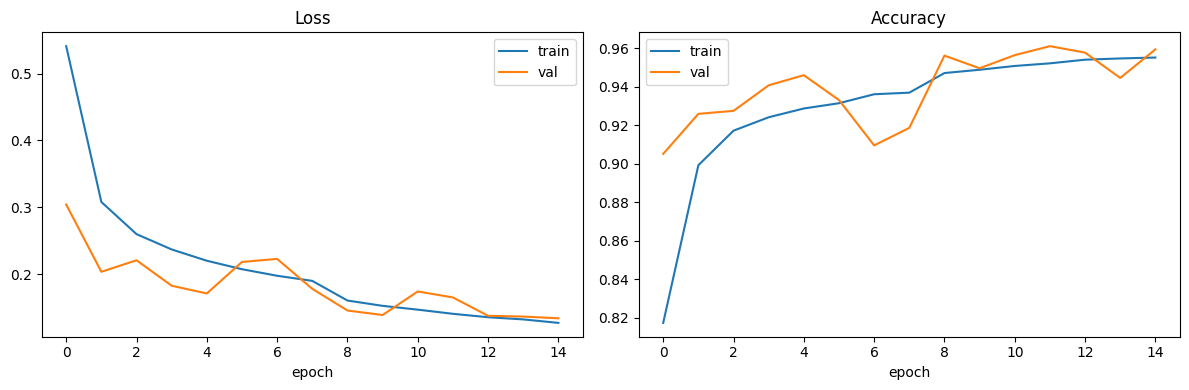

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

              precision    recall  f1-score   support

         CNV      0.979     0.968     0.973      3688
         DME      0.964     0.941     0.953      1152
      DRUSEN      0.888     0.878     0.883       850
      NORMAL      0.961     0.989     0.975      2658

    accuracy                          0.962      8348
   macro avg      0.948     0.944     0.946      8348
weighted avg      0.962     0.962     0.962      8348



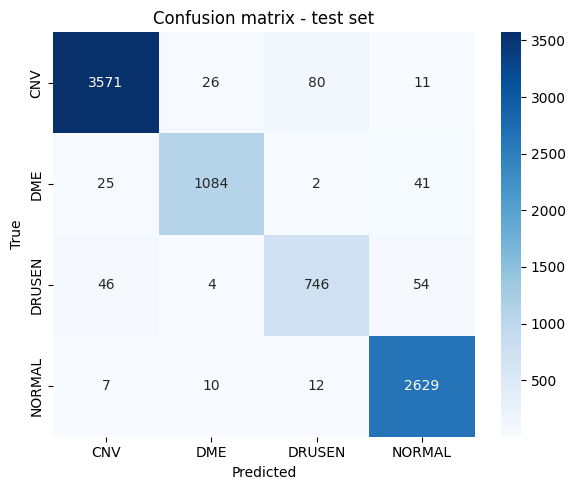

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix - test set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

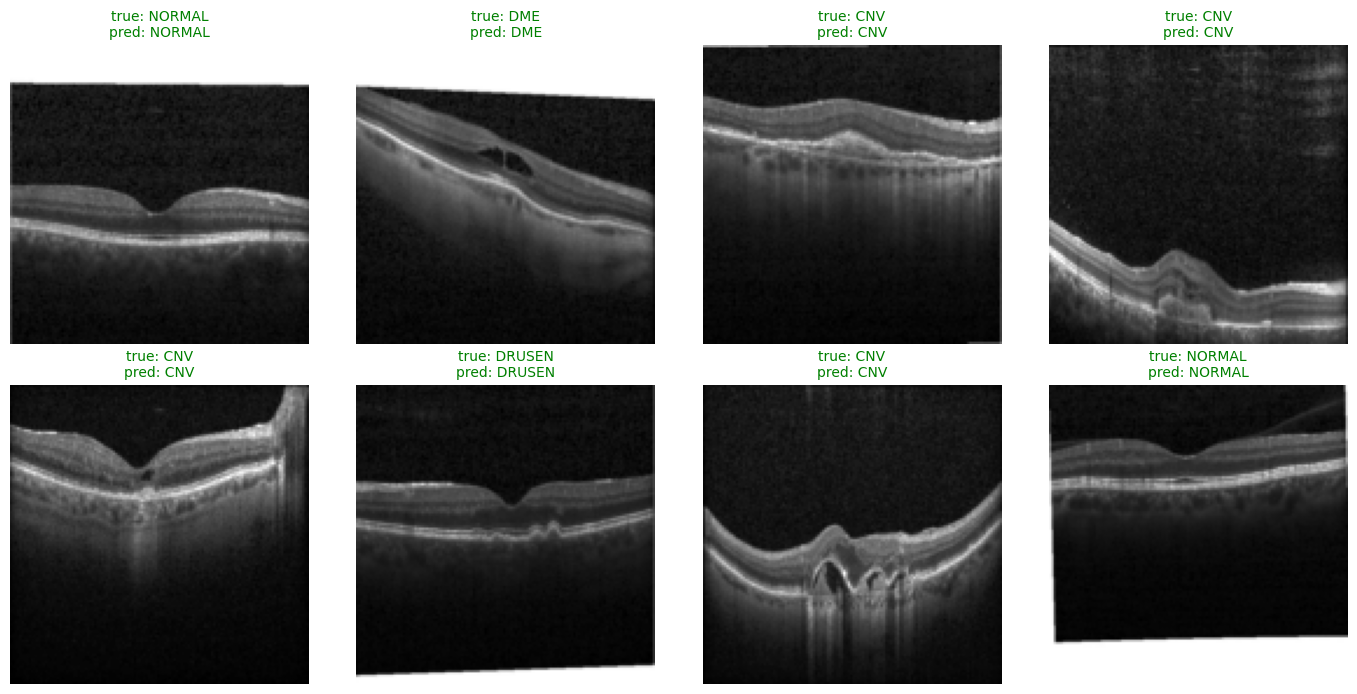

In [41]:
import random

model.eval()
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
sample_idxs = random.sample(range(len(test_ds_final)), 8)

with torch.no_grad():
    for ax, idx in zip(axes.flat, sample_idxs):
        img, label = test_ds_final[idx]
        pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        img_np = img.squeeze().numpy() * 0.5 + 0.5  # undo normalization for display

        ax.imshow(img_np, cmap="gray")
        color = "green" if pred == label else "red"
        ax.set_title(f"true: {class_names[label]}\npred: {class_names[pred]}", color=color, fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()

In [42]:
import shutil, os
os.makedirs("results", exist_ok=True)
for f in ["training_curves.png", "confusion_matrix.png", "sample_predictions.png"]:
    shutil.copy(f, f"results/{f}")

print("Final checkpoint saved at:", CHECKPOINT_PATH)
print("Best validation accuracy:", best_val_acc)

Final checkpoint saved at: /content/drive/MyDrive/oct_classifier_best.pt
Best validation accuracy: 0.9611883085769046
